# 05 — Feature-Group Ablation with Independent Retuning

**Input:** `data/processed/Longitudinal_Features_Dataset.csv`  
**Primary models:** XGBoost and Ridge  
**Outputs:** nested feature-addition results, leave-one-group-out ablations and fold-specific tuning records.

This notebook addresses the incremental feature-value component of RQ2 and RQ3. Each feature specification is treated as a separate modelling problem. Within every outer chronological fold, preprocessing and hyperparameters are selected again using only the corresponding inner training/validation data before the selected configuration is refitted on the complete outer-training sample and evaluated on the untouched next-season test set.

The evaluation sequence is:

`outer fold → feature specification → inner chronological split → training-only preprocessing → hyperparameter selection → refit on outer training data → outer prediction`

This avoids attributing a change in error to a feature group when it could instead reflect hyperparameters selected for a different predictor space.

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
import xgboost as xgb

ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
from src.analysis_utils import (
    paths, OUTER_FOLDS, FEATURE_GROUPS, FEATURE_COLS, TARGET,
    build_supervised_sample, split_outer, inner_chronological_split,
    prepare_train_test, regression_metrics, concat_unique
)
P=paths(ROOT)
with open(P['config']/'model_config.json',encoding='utf-8') as f: CFG=json.load(f)
SEED=CFG['random_seed']
warnings.filterwarnings('ignore')


## 1. Supervised sample and feature groups

The exact same target, eligibility rule and four outer folds from Notebook 04 are reused. Only the predictor set changes. Feature groups are explicit rather than automatically selected from all available columns.


In [2]:
feat=pd.read_csv(P['processed']/'Longitudinal_Features_Dataset.csv',dtype={'season':str})
_,elig=build_supervised_sample(feat)
print('Supervised transitions:',len(elig))
for g,cols in FEATURE_GROUPS.items(): print(f'{g:26s} {len(cols):2d} columns')
print('Full feature set:',len(FEATURE_COLS),'columns')
assert len(FEATURE_COLS)==45 and len(elig)==8350


Supervised transitions: 8350
current_performance         2 columns
trajectory_history          5 columns
age_exposure                6 columns
role                        3 columns
context_availability        9 columns
role_conditional_output    20 columns
Full feature set: 45 columns


## 2. Ablation specifications

Two complementary designs are used:

1. **Nested additions** start from current performance plus role and add trajectory, age/exposure, context and role-conditional outputs in sequence.
2. **Leave-one-group-out** starts from the full model and removes one conceptual group at a time.

The nested design asks what is gained as information is introduced. The leave-one-group-out design asks how much performance deteriorates when a group is removed from an otherwise complete model.


In [3]:
nested_specs={
    '1_current_plus_role': concat_unique(['current_performance','role']),
    '2_add_trajectory': concat_unique(['current_performance','role','trajectory_history']),
    '3_add_age_exposure': concat_unique(['current_performance','role','trajectory_history','age_exposure']),
    '4_add_context': concat_unique(['current_performance','role','trajectory_history','age_exposure','context_availability']),
    '5_full_add_role_output': FEATURE_COLS,
}
loo_specs={'full':FEATURE_COLS}
for group in FEATURE_GROUPS:
    loo_specs[f'without_{group}']=[c for c in FEATURE_COLS if c not in FEATURE_GROUPS[group]]

print('Nested:')
for k,v in nested_specs.items(): print(k,len(v))
print()
print('Leave-one-group-out:')
for k,v in loo_specs.items(): print(k,len(v))

Nested:
1_current_plus_role 5
2_add_trajectory 10
3_add_age_exposure 16
4_add_context 25
5_full_add_role_output 45

Leave-one-group-out:
full 45
without_current_performance 43
without_trajectory_history 40
without_age_exposure 39
without_role 42
without_context_availability 36
without_role_conditional_output 25


## 3. Independent inner tuning for every fold × specification

Ridge and XGBoost are both rerun so the feature conclusion is not tied to one model family. All preprocessing is fitted from the relevant inner-training data only.


In [4]:
def mae(y,p): return float(np.mean(np.abs(np.asarray(y)-np.asarray(p))))

def tune_ridge(train,fold,cols):
    it,iv=inner_chronological_split(train,fold)
    prep=prepare_train_test(it,iv,cols,scale=True)
    ytr=prep.train_df[TARGET].to_numpy(); yv=prep.test_df[TARGET].to_numpy()
    rows=[]
    for a in CFG['ridge_alpha_grid']:
        m=Ridge(alpha=a).fit(prep.X_train,ytr)
        rows.append(({'alpha':a},mae(yv,m.predict(prep.X_test))))
    return min(rows,key=lambda z:z[1]),rows

def tune_xgb(train,fold,cols):
    it,iv=inner_chronological_split(train,fold)
    prep=prepare_train_test(it,iv,cols,scale=False)
    ytr=prep.train_df[TARGET].to_numpy(); yv=prep.test_df[TARGET].to_numpy()
    rows=[]
    for params in CFG['xgboost_grid']:
        m=xgb.XGBRegressor(random_state=SEED,n_jobs=-1,subsample=0.8,colsample_bytree=0.8,reg_lambda=1.0,verbosity=0,**params)
        m.fit(prep.X_train,ytr)
        rows.append((params,mae(yv,m.predict(prep.X_test))))
    return min(rows,key=lambda z:z[1]),rows

def run_spec(spec_name,cols,design):
    pred_rows=[]; tune_rows=[]
    for fold in OUTER_FOLDS:
        train,test=split_outer(elig,fold)
        # Ridge
        (bp,bmae),grid=tune_ridge(train,fold,cols)
        for p,s in grid: tune_rows.append({'design':design,'spec':spec_name,'fold':fold['fold'],'model':'Ridge','inner_val_mae':s,'selected':p==bp,**p})
        prep=prepare_train_test(train,test,cols,scale=True)
        m=Ridge(**bp).fit(prep.X_train,prep.train_df[TARGET].to_numpy())
        pr=m.predict(prep.X_test)
        pred_rows.append(pd.DataFrame({'spec':spec_name,'design':design,'fold':fold['fold'],'model':'Ridge','y_true':test[TARGET].to_numpy(),'y_pred':pr}))
        # XGBoost
        (bp,bmae),grid=tune_xgb(train,fold,cols)
        for p,s in grid: tune_rows.append({'design':design,'spec':spec_name,'fold':fold['fold'],'model':'XGBoost','inner_val_mae':s,'selected':p==bp,**p})
        prep=prepare_train_test(train,test,cols,scale=False)
        m=xgb.XGBRegressor(random_state=SEED,n_jobs=-1,subsample=0.8,colsample_bytree=0.8,reg_lambda=1.0,verbosity=0,**bp)
        m.fit(prep.X_train,prep.train_df[TARGET].to_numpy())
        pr=m.predict(prep.X_test)
        pred_rows.append(pd.DataFrame({'spec':spec_name,'design':design,'fold':fold['fold'],'model':'XGBoost','y_true':test[TARGET].to_numpy(),'y_pred':pr}))
    return pd.concat(pred_rows,ignore_index=True),pd.DataFrame(tune_rows)


In [5]:
all_preds=[]; all_tuning=[]
for design,specs in [('nested',nested_specs),('leave_one_out',loo_specs)]:
    for spec,cols in specs.items():
        print('Running',design,spec,'with',len(cols),'features')
        p,t=run_spec(spec,cols,design)
        all_preds.append(p); all_tuning.append(t)
        # checkpoint after every specification
        pd.concat(all_preds,ignore_index=True).to_csv(P['predictions']/'05_ablation_predictions_checkpoint.csv',index=False)
        pd.concat(all_tuning,ignore_index=True).to_csv(P['tables']/'05_ablation_tuning_checkpoint.csv',index=False)

ablation_preds=pd.concat(all_preds,ignore_index=True)
ablation_tuning=pd.concat(all_tuning,ignore_index=True)
print('Prediction rows:',len(ablation_preds),'Tuning rows:',len(ablation_tuning))


Running nested 1_current_plus_role with 5 features


Running nested 2_add_trajectory with 10 features


Running nested 3_add_age_exposure with 16 features


Running nested 4_add_context with 25 features


Running nested 5_full_add_role_output with 45 features


...

Running leave_one_out without_age_exposure with 39 features


Running leave_one_out without_role with 42 features


Running leave_one_out without_context_availability with 36 features


Running leave_one_out without_role_conditional_output with 25 features


Prediction rows: 113808 Tuning rows: 672


## 4. Pooled ablation results

For each model/specification, predictions from all four untouched outer tests are concatenated before MAE is calculated. This matches the headline pooled-error definition in Notebook 04.


In [6]:
rows=[]
for (design,spec,model),g in ablation_preds.groupby(['design','spec','model']):
    rows.append({'design':design,'spec':spec,'model':model,**regression_metrics(g['y_true'],g['y_pred'])})
ablation_results=pd.DataFrame(rows)

nested=ablation_results[ablation_results['design']=='nested'].copy()
order=list(nested_specs)
nested['order']=nested['spec'].map({k:i for i,k in enumerate(order)})
nested=nested.sort_values(['model','order'])
display(nested[['model','spec','n','MAE','RMSE','R2','Spearman']].round(3))

loo=ablation_results[ablation_results['design']=='leave_one_out'].copy()
full_mae=loo[loo['spec']=='full'].set_index('model')['MAE'].to_dict()
loo['MAE_change_vs_full']=loo.apply(lambda r:r['MAE']-full_mae[r['model']],axis=1)
display(loo.sort_values(['model','MAE_change_vs_full'],ascending=[True,False])[['model','spec','n','MAE','MAE_change_vs_full']].round(3))


,model,spec,n,MAE,RMSE,R2,Spearman
14,Ridge,1_current_plus_role,4742,18.256,22.487,0.384,0.618
16,Ridge,2_add_trajectory,4742,17.628,21.682,0.427,0.653
18,Ridge,3_add_age_exposure,4742,17.597,21.682,0.427,0.654
20,Ridge,4_add_context,4742,17.628,21.693,0.427,0.654
22,Ridge,5_full_add_role_output,4742,17.566,21.581,0.433,0.658
15,XGBoost,1_current_plus_role,4742,18.225,22.494,0.384,0.616
17,XGBoost,2_add_trajectory,4742,17.484,21.691,0.427,0.651
19,XGBoost,3_add_age_exposure,4742,17.247,21.450,0.439,0.660
21,XGBoost,4_add_context,4742,17.270,21.464,0.439,0.659
23,XGBoost,5_full_add_role_output,4742,17.189,21.416,0.441,0.661


,model,spec,n,MAE,MAE_change_vs_full
6,Ridge,without_current_performance,4742,18.540,0.974
12,Ridge,without_trajectory_history,4742,17.939,0.372
10,Ridge,without_role_conditional_output,4742,17.628,0.062
2,Ridge,without_age_exposure,4742,17.587,0.021
8,Ridge,without_role,4742,17.584,0.017
0,Ridge,full,4742,17.566,0.000
4,Ridge,without_context_availability,4742,17.549,-0.017
13,XGBoost,without_trajectory_history,4742,17.808,0.619
7,XGBoost,without_current_performance,4742,17.743,0.554
3,XGBoost,without_age_exposure,4742,17.336,0.147


### Feature-value interpretation

For XGBoost, removing trajectory/history causes the largest deterioration in pooled MAE, followed by removing current-performance variables. Age/exposure and role-conditional football outputs contribute smaller additional improvements, while the available public context/availability variables add very little once performance, trajectory and age are represented. The result should be interpreted as evidence about the specific observable context variables available in this dataset, not as evidence that richer tactical, medical or contractual context is uninformative.

## 5. Export report-ready results

The pooled nested-addition and leave-one-group-out results are saved with the fold-specific tuning records. These outputs provide the numerical evidence for the dissertation's claims about current performance, longitudinal trajectory, age/exposure, context and role-conditional football output.

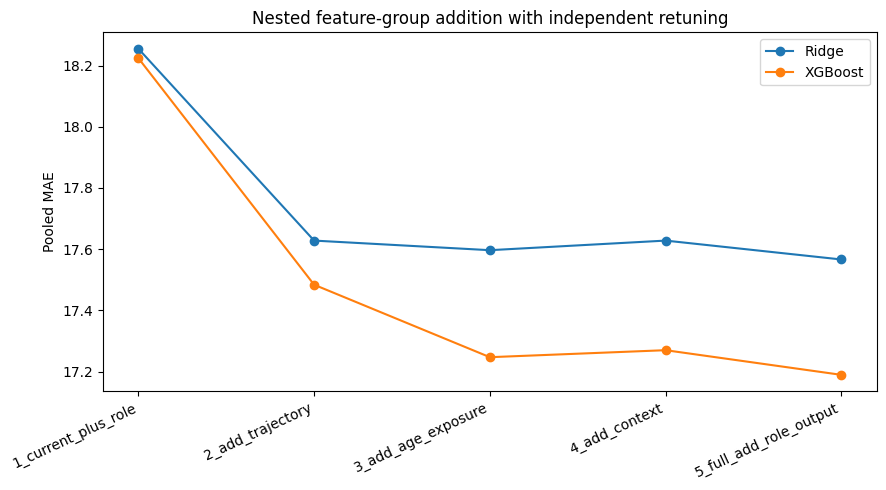

In [7]:
ablation_preds.to_csv(P['predictions']/'05_ablation_predictions.csv',index=False)
ablation_tuning.to_csv(P['tables']/'05_ablation_hyperparameter_tuning.csv',index=False)
ablation_results.to_csv(P['tables']/'05_feature_group_ablation_results.csv',index=False)
loo.to_csv(P['tables']/'05_leave_one_group_out_summary.csv',index=False)
nested.to_csv(P['tables']/'05_nested_feature_addition_summary.csv',index=False)

fig,ax=plt.subplots(figsize=(9,5))
for model,g in nested.groupby('model'):
    g=g.sort_values('order')
    ax.plot(g['order'],g['MAE'],marker='o',label=model)
ax.set_xticks(range(len(order)),order,rotation=25,ha='right')
ax.set_ylabel('Pooled MAE')
ax.set_title('Nested feature-group addition with independent retuning')
ax.legend()
fig.tight_layout(); fig.savefig(P['figures']/'05_nested_feature_group_ablation.png',dpi=160,bbox_inches='tight'); plt.show()


## Stage conclusion

The ablation results use the same chronological target and outer folds as the primary model comparison, while independently selecting model complexity for every reduced or expanded predictor specification. The leave-one-group-out design quantifies dependence on each group in the full model; the nested design shows how predictive error changes as information is added in a football-motivated sequence.